The purpose of this notebook is to take a csv file of all possible candidate control sources for each pulsar and calculate chi^2 and DoF values for every source, which will then allow me to sort by the chi^2 and DoF values to get the best possible control sources for each pulsar.

In [3]:
#imoprting required modules
import numpy as np
import pandas as pd

from astropy.coordinates import SkyCoord

from vasttools.query import Query

In [4]:
#calculates a weighted mean flux density for a single source
def weighted_mean_flux_density(source_df):
    sum_1overvariance = 0
    for i in np.arange(source_df.shape[0]):
        if (not np.isnan(source_df['flux_peak'].iloc[i])):
            oneOverVariance = 1 / source_df['rms_image'].iloc[i]
            sum_1overvariance += (oneOverVariance ** 2)
    sumSovervariance = 0
    for i in np.arange(source_df.shape[0]):
        if (not np.isnan(source_df['flux_peak'].iloc[i])):
            S = source_df['flux_peak'].iloc[i]
            var = source_df['rms_image'].iloc[i] **2
            sumSovervariance += (S/var)
    return sumSovervariance / sum_1overvariance       

In [5]:
#calculates chi_squared for a single source
def chi_squared(source_df):
    n_epochs = 0
    S_weighted = weighted_mean_flux_density(source_df)
    temp = 0
    for i in np.arange(source_df.shape[0]):
        if (not np.isnan(source_df['flux_peak'].iloc[i])):
            S = source_df['flux_peak'].iloc[i]
            var = source_df['rms_image'].iloc[i] ** 2
            num = (S - S_weighted)**2
            temp += num / var
            n_epochs += 1
    return (temp, n_epochs)

In [6]:
# make a query, and calculate a chi squared for the source found
def query_to_chi2(measurements_row):
    my_skycoord = SkyCoord(str(measurements_row.loc['ra_deg_cont']) + " " + str(measurements_row.loc['dec_deg_cont']), unit='deg')
    my_query = Query(coords=my_skycoord, epochs='all-vast', use_tiles=True, corrected_data=False, ncpu=1)
    my_query.find_sources()
    return chi_squared(my_query.results[0].measurements[my_query.results[0].measurements['freq']==887.5])

In [7]:
#datacube is cabinet, row df is a file in that cabinet, rows in the row_df are individual sources or items in the file

In [8]:
# using query_to_chi2, calculate and input a chi2 and nu_detections value into a given source dataframe
def intelligent_chi2_from_rowdf(row_df):
    counter = 0
    for i in row_df.index.values:
        row_df.loc[i, ['chi_squared', 'num_detections']] =  query_to_chi2(row_df.loc[i])
        if ((row_df.loc[i, 'chi_squared'] < 30)&(row_df.loc[i, 'num_detections'] > 20)):
            counter = counter + 1
        if (counter == 3):
            return "Completed"
    return "Completed"

In [ ]:
#this will get a giant dataframe of ALL candidate control sources for ALL psrs
#I don't actually run this cell as part of this notebook, but I am including it to give an idea of how I create the list of candidate control sources
cand_controls = []
names = []
for i in np.arange(modified_results.size):
    print(i) #debugging purposes
    query_coord = SkyCoord(str(modified_results[i].measurements['ra_deg_cont'].mean()) + " " + str(modified_results[i].measurements['dec_deg_cont'].mean()), unit='deg')
    new_query = Query(coords=query_coord, epochs='23', crossmatch_radius=3600., search_around_coordinates=True, use_tiles=True, corrected_data=False)
    new_query.find_sources()
    source_flux = modified_results[i].measurements['flux_peak'].median()
    new_results = new_query.results[(new_query.results['flux_peak']>source_flux)&(new_query.results['distance']>15)]
    new_results = new_results.reset_index()
    for j in np.arange(new_results.shape[0]):
        if not (new_results.loc[j]['flux_int'] < (1.5 * new_results.loc[j]['flux_peak'])):
            new_results.drop(j, inplace=True)
    new_results1 = new_results.sort_values('distance').reset_index(drop=True)
    cand_controls.append(new_results1)
    names.append(final_df[final_df['mod_results_index']==i]['JNAME'].values[0])

cand_controls_df = pd.concat(cand_controls, keys=names) #adds a multiindex based on the corresponding pulsar name for each candidate
cand_controls_df.to_csv('cand_controls.csv')

In [9]:
#read in your csv file of potential control sources
cands_df = pd.read_csv('cand_controls_truncated.csv', index_col=[0,1])

In [10]:
lists=[]
for i in np.arange(cands_df.index.levels[0].values.size):
    lists.append(cands_df.loc[cands_df.index.levels[0].values[i]])

In [11]:
#creating a series where each series element is a dataframe of candidate control sources for each pulsar
#this is done to more easily iterate through each set of candidate controls
temp_series = pd.Series(lists)

In [13]:
#inserting a placeholder columns for chi2 and DoF 
for i in np.arange(temp_series.size):
    temp_series[i].insert(0, 'chi_squared', np.nan)
    temp_series[i].insert(0, 'num_detections', np.nan)

In [14]:
import concurrent.futures

In [15]:
#calculating values and filling the placeholder columns.
#this cell uses multiprocessing to execute faster
with concurrent.futures.ThreadPoolExecutor() as executor:
    m = executor.map(intelligent_chi2_from_rowdf, temp_series)
    list(m) #need this part to make sure the thing actually executes. Look up "lazy evaluation" for more info 

Removing source_172207.0-315704.0: Epoch 5x due to missing files
Removing source_172207.0-315704.0: Epoch 6x due to missing files
Removing source_172207.0-315704.0: Epoch 8 due to missing files
Removing source_172207.0-315704.0: Epoch 20 due to missing files
Removing source_172207.0-315704.0: Epoch 21 due to missing files
Removing source_170754.7-351036.0: Epoch 5x due to missing files
Removing source_170754.7-351036.0: Epoch 6x due to missing files
Removing source_170754.7-351036.0: Epoch 8 due to missing files
Removing source_175048.5-315228.5: Epoch 13 due to missing files
Removing source_172101.6-352010.5: Epoch 5x due to missing files
Removing source_172101.6-352010.5: Epoch 6x due to missing files
Removing source_175048.5-315228.5: Epoch 20 due to missing files
Removing source_175048.5-315228.5: Epoch 21 due to missing files
Removing source_172101.6-352010.5: Epoch 8 due to missing files
Removing source_172101.6-352010.5: Epoch 20 due to missing files
Removing source_172101.6-352

In [34]:
#exporting each dataframe to a csv file named after its associated pulsar
psrs = cands_df.index.levels[0]
for i in np.arange(temp_series.size):
    temp_series[i].to_csv(psrs[i] + '_controls.csv')

In [19]:
#sorting by chi2
for i in np.arange(temp_series.size):
    temp_series[i].sort_values('chi_squared', inplace=True)

In [21]:
#creating a new iterable 'thing_list' which removes all candidate control sources that have a low number of detections
thing_list = []
for i in np.arange(temp_series.size):
    labels = temp_series[i][temp_series[i]['num_detections']<20].index.values
    thing = temp_series[i].drop(labels)
    thing_list.append(thing)
    print(thing.shape[0]) #this print statement is included to help verify that no pulsars have zero control sources with >20 detections, and will have empty dataframes as a result

9
31
1
19
66
5
16
101
38
71
54
8
20
25
4
4
33
63
46
82
94
2
81
101
25
44
147
93
2
22
15
125
68
3
118
6
43
15
2
19
68
56
172
26


In [116]:
#creating csv of chi2 of the two lowest variability control sources for each pulsar. Useful for plotting purposes
chi_squareds = []
for i in np.arange(len(thing_list)):
    chi_squareds.append(thing_list[i]['chi_squared'].iloc[0])
    chi_squareds.append(thing_list[i]['chi_squared'].iloc[1])
pd.Series(chi_squareds).to_csv('control_chi_squareds.csv')

In [10]:
#reading this csv to a variable
chi_squareds = pd.read_csv('control_chi_squareds.csv')

In [77]:
chi_squareds = list(chi_squareds['0'])

In [122]:
for i in chi_squareds:
    if i > 200:
        chi_squareds.remove(i)

In [66]:
import matplotlib.pyplot as plt
%matplotlib inline

AttributeError: module 'matplotlib.pyplot' has no attribute 'set_ylabel'

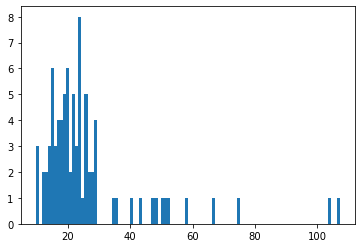

In [79]:
plt.hist(chi_squareds, bins=100)
plt.set_ylabel('Chi Squared')

In [131]:
#creating a list of the 'final candidates': the two least variable control sources for each pulsar
final_cands_list = []
for i in np.arange(len(thing_list)):
    final_cands_list.append(thing_list[i].iloc[0])
    final_cands_list.append(thing_list[i].iloc[1])

In [132]:
final_cands_df = pd.DataFrame(final_cands_list)

In [133]:
#adding a placeholder column which will be filled with the pulsar partners for each control source
final_cands_df.insert(0, 'PSR_assoc', None)

In [136]:
final_cands_df.reset_index(inplace=True)

In [149]:
#filling the placeholder column
counter = 0
j = 0
for i in final_cands_df.index.values:
    final_cands_df.loc[i, 'PSR_assoc'] = cands_df.index.levels[0].values[j]
    counter = counter + 1
    if (counter==2):
        j = j+1
        counter = 0

In [153]:
#exporting to a csv file
final_cands_df.to_csv('final_controls.csv')